# Radio Synchrotron Modelling Analysis

This is a separate notebook just so I don't have to keep rerunning the chains when they look fine

In [2]:
import os
import glob
import json
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo

from corner import corner

from astropy import constants as c
from astropy import units as u

import syncfit

from otter import Otter

private_data_path = "private_otter_data"
db = Otter(
    url="https://dev.sites.idies.jhu.edu/86164ceed11eed6b9fc64fb9c7e00494/api",
    username="user-guest",
    password="test",
    datadir=private_data_path,
    gen_summary=False
)

Attempting to login with the following credentials:
username: user-guest
password: test


In [3]:
# the upperlimits based on the posterior distributions
# I'm just defining these by hand 

param_uplims = dict(
    name = ['SDSSJ1241', 'SDSSJ1241', 'SDSSJ0938', 'SDSSJ0938', 'SDSSJ0748', 'SDSSJ0748'],
    mjd = ['57629.5', '57959.0', '57459.0', '57912.0', '57458.0', '57914.0'],
    p_lim = [False, False, False, False, False, False], # these would be upperlimits
    p_lim_type = "upper",
    log_F_nu_lim = [True, False, True, True, True, True], # these are lower limits
    log_F_nu_lim_type = "lower",
    log_nu_a_lim = [True, False, True, True, True, True], # these are upperlimits on nu_a
    log_nu_a_lim_type = "upper"
)

In [4]:
def get_bounds(chain, ndim=3):
    
    medians, upper, lower = [], [], []
    for i in range(ndim):
        mcmc = np.percentile(chain[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        vals = [mcmc[1],(q[0]+q[1])/2]

        medians.append(mcmc[1])
        upper.append(q[1])
        lower.append(q[0])

    return medians, upper, lower

def get_single_bound(chain1d):
    mcmc = np.percentile(chain1d, [16, 50, 84])
    q = np.diff(mcmc)
    
    return mcmc[1], q[1], q[0]

def virial_r(fwhm, M=1e6*c.M_sun):
    return (c.G*M/fwhm**2).to(u.cm)

In [5]:
labels = ["p", 'log_F_nu', 'log_nu_a']

best_fit_params = dict(
    name = [],
    mjd = [],
    p = [],
    p_up = [],
    p_lo = [],
    p_chain = [],
    log_F_nu = [],
    log_F_nu_up = [],
    log_F_nu_lo = [],
    log_F_nu_chain = [],
    log_nu_a = [],
    log_nu_a_up = [],
    log_nu_a_lo = [],
    log_nu_a_chain = []
)

for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):

    with open(jfile, "r") as j:
        chain_dict = json.load(j)
    
    tname = jfile.split('-')[1].split('/')[1]

    print(tname)

    for k, chain in chain_dict.items():
        medians, uplims, lowlims = get_bounds(np.array(chain))
        print(f"\tMJD = {k}")
        for median, uplim, lowlim, lab, chain_by_key in zip(medians, uplims, lowlims, labels, np.array(chain).T):
            print(f"\t\t${lab} = {median:.2f}^+{uplim:.2f}_-{lowlim:.2f}$")

            best_fit_params[lab].append(median)
            best_fit_params[f"{lab}_up"].append(uplim)
            best_fit_params[f"{lab}_lo"].append(lowlim)
            best_fit_params[f"{lab}_chain"].append(chain_by_key)
        best_fit_params["mjd"].append(k)
        best_fit_params["name"].append(tname)
        
        
    
    print()

res = pd.DataFrame(best_fit_params).merge(pd.DataFrame(param_uplims), on=["name", "mjd"])

res

SDSSJ1241
	MJD = 57959.0
		$p = 3.92^+0.06_-0.08$
		$log_F_nu = 1.18^+0.02_-0.02$
		$log_nu_a = 8.99^+0.02_-0.02$
	MJD = 57629.5
		$p = 3.88^+0.09_-0.08$
		$log_F_nu = 1.08^+0.27_-0.11$
		$log_nu_a = 9.10^+0.10_-0.21$

SDSSJ0938
	MJD = 57912.0
		$p = 3.08^+0.12_-0.08$
		$log_F_nu = 1.30^+0.46_-0.29$
		$log_nu_a = 8.36^+0.36_-0.47$
	MJD = 57459.0
		$p = 3.11^+0.09_-0.10$
		$log_F_nu = 1.31^+0.47_-0.47$
		$log_nu_a = 8.49^+0.46_-0.45$

SDSSJ0748
	MJD = 57914.0
		$p = 2.59^+0.34_-0.31$
		$log_F_nu = 0.41^+0.84_-0.71$
		$log_nu_a = 7.65^+1.03_-1.05$
	MJD = 57458.0
		$p = 2.62^+0.13_-0.13$
		$log_F_nu = 0.65^+0.89_-0.89$
		$log_nu_a = 7.80^+1.11_-1.11$



,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,log_nu_a,log_nu_a_up,log_nu_a_lo,log_nu_a_chain,p_lim,p_lim_type,log_F_nu_lim,log_F_nu_lim_type,log_nu_a_lim,log_nu_a_lim_type
0,SDSSJ1241,57959.0,3.920903,0.055025,0.083077,"[3.0049657740184856, 3.0010281263657257, 3.000...",1.175365,0.016536,0.018017,"[0.9909119054822503, 0.9941782983059854, 1.001...",8.985699,0.015542,0.018391,"[9.004773770689694, 9.005620889821733, 9.00438...",False,upper,False,lower,False,upper
1,SDSSJ1241,57629.5,3.877922,0.085578,0.076951,"[3.9340857138140164, 3.9190376794936714, 3.914...",1.083294,0.265146,0.111470,"[1.0086813402090888, 1.0041549375264336, 1.001...",9.097637,0.097095,0.209720,"[9.014806338127073, 8.991528032374617, 8.99059...",False,upper,True,lower,True,upper
2,SDSSJ0938,57912.0,3.081853,0.122519,0.081857,"[3.0010275068929424, 2.990421810647745, 3.0069...",1.297415,0.464983,0.293400,"[0.9922377944666052, 1.0054323015722957, 0.992...",8.364478,0.357438,0.469244,"[8.992932069207582, 8.99462094165873, 8.996872...",False,upper,True,lower,True,upper
3,SDSSJ0938,57459.0,3.112252,0.092424,0.095087,"[3.0833806643032777, 3.072689053518213, 3.0783...",1.309558,0.471109,0.473921,"[0.9954455437367415, 1.002645844777471, 1.0036...",8.492400,0.460347,0.449157,"[8.995816474222346, 8.98174014795783, 9.001467...",False,upper,True,lower,True,upper
4,SDSSJ0748,57914.0,2.590281,0.340513,0.306848,"[2.9971661030039187, 2.9927683159084366, 2.993...",0.409951,0.844192,0.713918,"[1.0032325646876552, 1.0047088985977595, 1.007...",7.649368,1.032083,1.047648,"[8.993203037688165, 8.990993712105132, 8.99359...",False,upper,True,lower,True,upper
5,SDSSJ0748,57458.0,2.615977,0.128486,0.125098,"[2.5893171848730145, 2.5979619176830204, 2.580...",0.645441,0.887906,0.891467,"[0.9920297540159176, 1.0077216786031211, 0.993...",7.798951,1.107213,1.109432,"[8.994662666024636, 8.992907377339106, 9.00755...",False,upper,True,lower,True,upper


In [6]:
# add in other information we need about each object

SDSSJ1241_meta = db.get_meta(names="SDSS_J1241", query_private=True)[0]
SDSSJ0938_meta = db.get_meta(names="SDSS_J0938", query_private=True)[0]
SDSSJ0748_meta = db.get_meta(names="SDSS_J0748", query_private=True)[0]

redshift = dict(
    SDSSJ1241 = SDSSJ1241_meta.get_redshift(),
    SDSSJ0938 = SDSSJ0938_meta.get_redshift(),
    SDSSJ0748 = SDSSJ0748_meta.get_redshift()
)

disc_date = dict(
    SDSSJ1241 = SDSSJ1241_meta.get_discovery_date().mjd,
    SDSSJ0938 = SDSSJ0938_meta.get_discovery_date().mjd,
    SDSSJ0748 = SDSSJ0748_meta.get_discovery_date().mjd
)

lum_dist = dict(
    SDSSJ1241 = None,
    SDSSJ0938 = None,
    SDSSJ0748 = None
)

# I get all of these velocity dispersions by querying SDSS for the coordinates from the name
vel_disp = dict(
    SDSSJ0748 = 79.33013,
    SDSSJ0938 = 126.8426,
    SDSSJ1241 = 85.12043
)

vel_disp_err = dict(
    SDSSJ0748 = 8.36008,
    SDSSJ0938 = 9.147189,
    SDSSJ1241 = 11.9128
)

for name, z in redshift.items():
    lum_dist[name] = cosmo.luminosity_distance(z).to("cm").value

res['z'] = res.name.map(redshift).astype(float)
res["lum_dist"] = res.name.map(lum_dist).astype(float)
res["disc_date"] = res.name.map(disc_date).astype(float)

res["vel_disp"] = res.name.map(vel_disp).astype(float)
res["vel_disp_err"] = res.name.map(vel_disp_err).astype(float)

# compute the black hole mass using M-sigma
# Using this relation: https://iopscience.iop.org/article/10.1088/0004-637X/698/1/198
def Msigma(sigma_km_s):
    alpha = 8.12
    beta = 4.24
    return alpha + beta*np.log10(sigma_km_s/200)
    
res["log_M_bh"] = Msigma(res.vel_disp)
res["M_bh"] = 10**res.log_M_bh

# then calculate the swarschild radius
def R_s(M_bh):
    r_s = 2*c.G*M_bh/c.c**2
    return r_s.cgs.value

res["R_s"] = R_s(res.M_bh.to_numpy()*c.M_sun)

res["dt"] = res.mjd.astype(float) - res.disc_date

# determine if each F_nu, p, and log_nu should be upperlimits
def is_upperlimit(df, key, model=syncfit.models.B5(), uplim_factor=3):
    
    key_prior = model.prior[key]
    
    median = df[key]
    up = df[f"{key}_up"]
    lo = df[f"{key}_lo"]
        
    return median+(up*uplim_factor) > key_prior[1]
    
    
res["log_F_nu_uplim"] = is_upperlimit(res, "log_F_nu")
res["log_nu_a_uplim"] = is_upperlimit(res, "log_nu_a")
res["p_uplim"] = is_upperlimit(res, "p")

res

Names have the same score! Just using the existing default_name


,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,disc_date,vel_disp,vel_disp_err,log_M_bh,M_bh,R_s,dt,log_F_nu_uplim,log_nu_a_uplim,p_uplim
0,SDSSJ1241,57959.0,3.920903,0.055025,0.083077,"[3.0049657740184856, 3.0010281263657257, 3.000...",1.175365,0.016536,0.018017,"[0.9909119054822503, 0.9941782983059854, 1.001...",...,53062.0,85.12043,11.912800,6.546976,3.523515e+06,1.040582e+12,4897.0,False,False,True
1,SDSSJ1241,57629.5,3.877922,0.085578,0.076951,"[3.9340857138140164, 3.9190376794936714, 3.914...",1.083294,0.265146,0.111470,"[1.0086813402090888, 1.0041549375264336, 1.001...",...,53062.0,85.12043,11.912800,6.546976,3.523515e+06,1.040582e+12,4567.5,False,False,True
2,SDSSJ0938,57912.0,3.081853,0.122519,0.081857,"[3.0010275068929424, 2.990421810647745, 3.0069...",1.297415,0.464983,0.293400,"[0.9922377944666052, 1.0054323015722957, 0.992...",...,54092.0,126.84260,9.147189,7.281477,1.911952e+07,5.646472e+12,3820.0,True,False,False
3,SDSSJ0938,57459.0,3.112252,0.092424,0.095087,"[3.0833806643032777, 3.072689053518213, 3.0783...",1.309558,0.471109,0.473921,"[0.9954455437367415, 1.002645844777471, 1.0036...",...,54092.0,126.84260,9.147189,7.281477,1.911952e+07,5.646472e+12,3367.0,True,False,False
4,SDSSJ0748,57914.0,2.590281,0.340513,0.306848,"[2.9971661030039187, 2.9927683159084366, 2.993...",0.409951,0.844192,0.713918,"[1.0032325646876552, 1.0047088985977595, 1.007...",...,52935.0,79.33013,8.360080,6.417251,2.613669e+06,7.718819e+11,4979.0,True,False,False
5,SDSSJ0748,57458.0,2.615977,0.128486,0.125098,"[2.5893171848730145, 2.5979619176830204, 2.580...",0.645441,0.887906,0.891467,"[0.9920297540159176, 1.0077216786031211, 0.993...",...,52935.0,79.33013,8.360080,6.417251,2.613669e+06,7.718819e+11,4523.0,True,True,False


In [7]:
def _mini_converter(d_L, nu_p):
    '''
    Converts to the appropriate units for the paper
    '''
    return d_L/1e28, nu_p/1e10

def Gamma(F_p_mJy, nu_p, z, d_L, t_d, eta=1, f_V=0.36, f_A=1):
    """
    Barniol Duran Eq. 4
    """
    d_L, nu_p = _mini_converter(d_L, nu_p)
    Req
    prefactor = 12
    midfactor = F_p_mJy**(1/3) * d_L**(2/3) * nu_p**(-17/24) * eta**(35/72) * (1+z)**(-1/3) * t_d**(-17/24)
    postfactor = f_A**(-7/24) * f_V**(-1/24)
        
    return prefactor * midfactor * postfactor
    
def beta(t, R, z):
    """
    Barniol Duran Eq. 22
    """
    return ((c.c.cgs.value * t / (R*(1+z)) ) + 1)**-1

def Req(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, epsilon_B=None, gamma=1, f_V=0.36, f_A=1, nu_m=None):
    """
    Barniol Duran Eq. 27
    """
    
    # convert into proper units
    d_L28, nu_p10 = _mini_converter(d_L, nu_p)
    
    # deal with epsilon e and B corrections to the radius (end of sec. 3)
    # if epislon_B is None, assume equipartition model
    if epsilon_B is None:
        epsilon = 1 
    else:
        epsilon = 11/6 * (epsilon_B/epsilon_e)
    
    if gamma <= 1:
        epsilon_correction = epsilon**(1/17)
    else:
        # use the relativistic correction
        epsilon_correction = epsilon**(1/12)
        gamma = gamma*epsilon**(1/24)
        
    # hot proton correction factor (sec. 4.2.2)
    xi = 1 + epsilon_e**-1
    hot_proton_correction = xi**(1/(13+2*p))
    
    # correct for electrons that radiate at nu_m (sec. 4.2.1)
    # if nu_m is not None: # this still assumes nu_m < nu_a (almost always true for TDEs)
    #     y_e = gamma_e(F_p_mJy, d_L, nu_p, z, R_17, gamma=gamma, f_A=f_A)
    #     gamma_m = y_e * (nu_m/nu_p)**(1/2)
    # else:
    chi_e = (p-2)/(p-1) * epsilon_e * c.m_p.cgs.value/c.m_e.cgs.value
    gamma_m = np.max(np.array([
        np.ones(len(chi_e))*2 if isinstance(chi_e, (list, np.ndarray, pd.Series)) else 2,
        chi_e*(gamma-1)
    ]), axis=0)
    gamma_factor = gamma_m**((2-p)/(13+2*p))
    
    # if gamma is less than 1 we have to do a newtonian correction to these models
    # (beginning of sec. 3)
    newtonian_correction = 1
    if gamma <= 1:
        newtonian_correction = 4**(1/(13+2*p))
    
    # the traditional model without any of the above corrections
    prefactor = 1e17 * (21.8 * 525**(p-1))**(1/(13+2*p))
    midfactor = F_p_mJy**((6+p)/(13+2*p)) * d_L28**((2*(p+6))/(13+2*p)) * nu_p10**(-1) * (1+z)**-((19+3*p)/(13+2*p)) 
    postfactor= f_A**-((5+p)/(13+2*p)) * f_V**-(1/(13+2*p)) * gamma**((p+8)/(13+2*p))
    
    return prefactor * midfactor * postfactor * gamma_factor * newtonian_correction * epsilon_correction * hot_proton_correction

def Eeq(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, epsilon_B=None, gamma=1, f_V=0.36, f_A=1, nu_m=None):
    """
    Barniol Duran Eq. 28 
    """
    
    # convert into the proper units for Barniol-Duran
    d_L28, nu_p10 = _mini_converter(d_L, nu_p)
    
    # deal with epsilon e and B corrections to the energy (end of sec. 3)
    # if epislon_B is None, assume equipartition model 
    if epsilon_B is None:
        epsilon = 1
    else:
        epsilon = 11/6 * (epsilon_B/epsilon_e)
    
    if gamma <= 1:
        epsilon_correction = (11/17)*epsilon**(-6/17) + (6/17)*epsilon**(11/17)
    else:
        # use the relativistic correction
        epsilon_correction = (11/17)*epsilon**(-5/12) + (6/17)*epsilon**(7/12)
    
    # hot proton correction factor (sec. 4.2.2)
    xi = 1 + epsilon_e**-1
    hot_proton_correction = xi**(11/(13+2*p))
    
    # correct for electrons that radiate at nu_m (sec 4.2.1)
    # if nu_m is not None: # this still assumes nu_m < nu_a (almost always true for TDEs)
    #     y_e = gamma_e(F_p_mJy, d_L, nu_p, z, R_17, gamma=gamma, f_A=f_A)
    #     gamma_m = y_e * (nu_m/nu_p)**(1/2)
    # else:
    chi_e = (p-2)/(p-1) * epsilon_e * c.m_p.cgs.value/c.m_e.cgs.value
    gamma_m = np.max(np.array([
        np.ones(len(chi_e))*2 if isinstance(chi_e, (list, np.ndarray, pd.Series)) else 2,
        chi_e*(gamma-1)
    ]), axis=0)
    gamma_factor = gamma_m**(-11*(p-2)/(13+2*p))
    
    # correct the relativistic equations for newtonian 
    # (beginning of sec. 3)
    newtonian_correction = 1
    if gamma <= 1:
        newtonian_correction = 4**(11/(13+2*p))
    
    prefactor = 1.3e48 * 21.8**-(2*(p+1)/(13+2*p)) * 525**((11*(p-1)/(13+2*p)))
    midfactor = F_p_mJy**((14+3*p)/(13+2*p)) * d_L28**(2*(3*p+14)/(13+2*p)) * nu_p10**(-1) * (1+z)**(-(27+5*p)/(13+2*p))
    postfactor= f_A**(-3*(p+1)/(13+2*p)) * f_V**(2*(p+1)/(13+2*p)) * gamma**-((5*p+16)/(13+2*p))

    return prefactor * midfactor * postfactor * gamma_factor * newtonian_correction * epsilon_correction * hot_proton_correction

def gamma_e(F_p_mJy, d_L, nu_p, z, R_17, gamma=1, f_A=1, eta=1):
    """
    Barniol-Duran eq. 14
    """
    d_L, nu_p = _mini_converter(d_L, nu_p)
    
    prefactor = 525
    midfactor = F_p_mJy * d_L**2 * nu_p**-2 * eta**(5/3) * (1+z)**-3
    postfactor = gamma/(f_A*R_17**2)

    return prefactor * midfactor * postfactor
    
def N_e(p, F_p_mJy, d_L, nu_p, z, R_17, gamma=1, f_A=1, eta=1, epsilon_e=0.1, nu_m=None):
    """
    Assumes a spherical outflow, Eq. 15
    """
    
    y_e = gamma_e(F_p_mJy, d_L, nu_p, z, R_17, gamma=gamma, f_A=f_A, eta=eta)
    
    d_L, nu_p = _mini_converter(d_L, nu_p)
    
    chi_e = (p-2)/(p-1) * epsilon_e * c.m_p.cgs.value/c.m_e.cgs.value
    gamma_m = np.max(np.array([
        np.ones(len(chi_e))*2 if isinstance(chi_e, (list, np.ndarray, pd.Series)) else 2,
        chi_e*(gamma-1)
    ]), axis=0)

    # conversion factor from Cendes+2021 to isotropic N_e
    gamma_factor = 4 * (y_e/gamma_m)**(p-1)
    
    prefactor = 1e54
    midfactor = (F_p_mJy**3 * d_L**6 * nu_p**-5 * eta**(10/3) * (1+z)**-8)
    postfactor = 1/(f_A**2 * R_17**4)
        
    return gamma_factor * prefactor * midfactor * postfactor
    
    
def n_e(p, F_p_mJy, d_L, nu_p, z, R_17, gamma=1, f_A=1, eta=1, emitting_region_width_fraction=0.1, epsilon_e=0.1):
    
    # number of electrons
    N = N_e(p, F_p_mJy, d_L, nu_p, z, R_17, gamma=gamma, f_A=f_A, eta=eta, epsilon_e=0.1)

    # volume of emitting region
    R = 1e17 * R_17
    V = 4/3*np.pi * (R**3 - ( (1-emitting_region_width_fraction) * R )**3)
    
    # convert from N_e to n_e using the same method as Eftekhari+18
    # electron number density inside the shock
    n_e = N / V 
    
    # convert to electron number density outside the shock using the jump conditions
    n_ext = n_e / (4*gamma**2)
    
    return n_ext

def draw_limit_arrow(df, ax, direction, ratio=3, xkey='Req', ykey="n_e", norm_Req=True, **kwargs):
        
    if xkey == "Req" and norm_Req:
        center_xs = df.Req/df.R_s
    else:
        center_xs = df[xkey]
    
    print(len(df))
    
    center_ys = df[ykey]
        
    if direction == "left":
        u = -1*np.ones(len(df))
        v = np.zeros(len(df))
        
    elif direction == "right":
        u = np.ones(len(df))
        v = np.zeros(len(df))
    
    elif direction == "up":
        u = np.zeros(len(df))
        v = np.ones(len(df))
        
    elif direction == "down":
        u = np.zeros(len(df))
        v = -1*np.ones(len(df))
    
    else:
        raise Exception()
    
    ax.quiver(
        center_xs,
        center_ys,
        u,
        v,
        width=0.002,
        headwidth=5,
        scale_units="inches",
        **kwargs
    )

In [8]:
equipartition_results = dict( 
    name = [],
    mjd = [],
    
    n_e_chain = [],
    n_e = [],
    n_e_up = [],
    n_e_lo = [],
    n_e_lim = [False, True, True, True, True, True],
    n_e_lim_type = 'upper',
    
    Req_chain = [],
    Req = [],
    Req_up = [],
    Req_lo = [],
    Req_lim = [False, True, True, True, True, True],
    Req_lim_type = 'lower',
    
    Eeq_chain = [],
    Eeq = [],
    Eeq_up = [],
    Eeq_lo = [],
    Eeq_lim = [False, True, True, True, True, True],
    Eeq_lim_type = 'lower',
)

gamma = 1

for _, row in res.iterrows():
    
    equipartition_results["name"].append(row['name'])
    equipartition_results["mjd"].append(row.mjd)
    
    r_eq_val = Req(
        p = row.p_chain, 
        F_p_mJy = 10**row.log_F_nu_chain, 
        nu_p = 10**row.log_nu_a_chain, 
        z = row.z, 
        d_L = row.lum_dist
    )
        
    equipartition_results["Req_chain"].append(r_eq_val)
    req, req_up, req_lo = get_single_bound(r_eq_val)
    
    equipartition_results["Req"].append(np.median(req))
    equipartition_results["Req_up"].append(req_up)
    equipartition_results["Req_lo"].append(req_lo)
    
    
    e_eq_val = Eeq(
        p = row.p_chain, 
        F_p_mJy = 10**row.log_F_nu_chain, 
        nu_p = 10**row.log_nu_a_chain, 
        z = row.z, 
        d_L = row.lum_dist
    )
    
    equipartition_results["Eeq_chain"].append(e_eq_val)
    eeq, eeq_up, eeq_lo = get_single_bound(e_eq_val)
    
    equipartition_results["Eeq"].append(eeq)
    equipartition_results["Eeq_up"].append(eeq_up)
    equipartition_results["Eeq_lo"].append(eeq_lo)
    
    n_e_val = n_e(
        p = row.p_chain,
        F_p_mJy = 10**row.log_F_nu_chain,
        d_L = row.lum_dist,
        nu_p = 10**row.log_nu_a_chain,
        z = row.z,
        R_17 = r_eq_val/1e17
    )
    
    equipartition_results["n_e_chain"].append(n_e_val)
    ne, ne_up, ne_lo = get_single_bound(n_e_val)
    
    equipartition_results["n_e"].append(ne)
    equipartition_results["n_e_up"].append(ne_up)
    equipartition_results["n_e_lo"].append(ne_lo)

results_df = res.merge(pd.DataFrame(equipartition_results), on=["name", "mjd"])

results_df.n_e

0    41.435794
1    68.901251
2     0.573359
3     1.109553
4     0.018263
5     0.035357
Name: n_e, dtype: float64

/home/nfranz/.local/lib/lib/python3.12/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/lib/python3.12/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/lib/python3.12/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/lib/python3.12/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


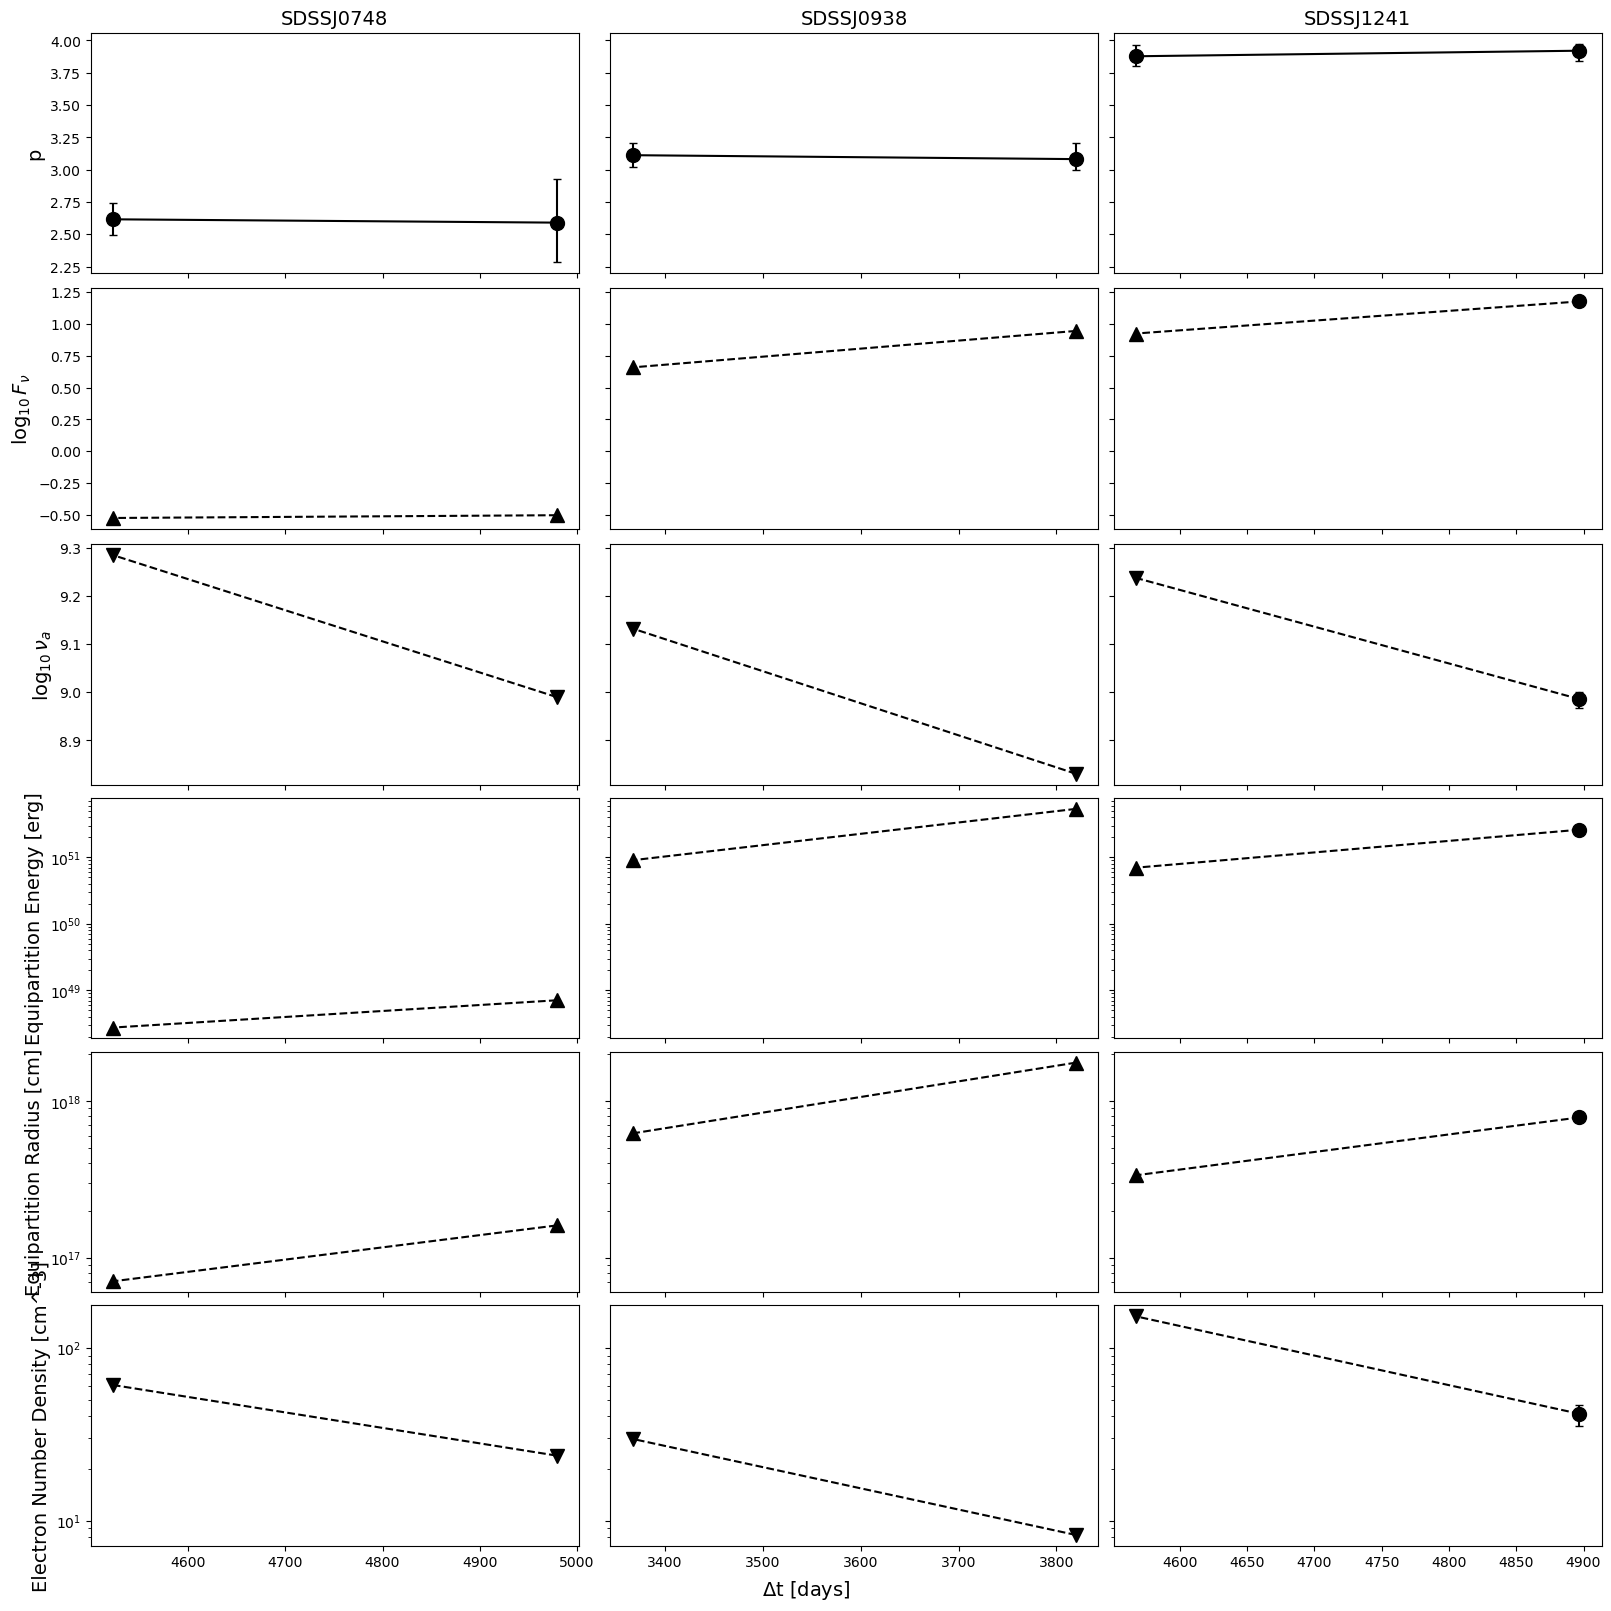

In [9]:
keys = {
    "p" : "p",
    "log_F_nu": r"$\log_{10} F_{\nu}$",
    "log_nu_a": r"$\log_{10} \nu_a$",
    "Eeq" : "Equipartition Energy [erg]",
    "Req" : "Equipartition Radius [cm]",
    "n_e" : "Electron Number Density [cm^-3]"
}

ranges = {
    "Eeq" : (1e48, 1e52),
    "Req" : (1e17, 1e20),
    "p": (2,4),
    "log_F_nu": (0,5),
    "log_nu_a": (6,10),
}

fig, axs = plt.subplots(len(keys),3, sharex="col", sharey="row", figsize=(16,16), layout="constrained")

xvar = "dt"

conf_level = 0.95

priors = syncfit.models.B5().prior
ranges = priors | ranges # this will default to the priors but replace them with anything in ranges

label_fs = 14
ms = 10

for idx, (ax1d, (key, label)) in enumerate(zip(axs, keys.items())):
    ax1d[0].set_ylabel(label, fontsize=label_fs)
    for jj, (ax, (name, grp)) in enumerate(zip(ax1d, results_df.groupby("name"))):
        cplot = 'k'

        not_uplim = grp[~grp[key+"_lim"]]
        ax.errorbar(
            not_uplim[xvar], 
            not_uplim[key], 
            yerr=(not_uplim[key+"_lo"], not_uplim[key+"_up"]), 
            marker='o', 
            linestyle='none', 
            color=cplot,
            capsize=3,
            markersize=ms
        )

        uplims = grp[grp[key+"_lim"]]
        if len(uplims) > 0:
            lim_type = uplims[key+"_lim_type"].iloc[0]
            symb = 'v' if lim_type == "upper" else '^'
            
            # compute the 95% confidence limit
            if lim_type == "upper":
                grp.loc[uplims.index,key] = [np.quantile(c, conf_level) for c in uplims[key+"_chain"]]
            elif lim_type == "lower":
                grp.loc[uplims.index,key] = [np.quantile(c, 1-conf_level) for c in uplims[key+"_chain"]]
            
            ax.plot(
                grp.loc[uplims.index, xvar],
                grp.loc[uplims.index, key],
                marker=symb,
                linestyle='none',
                color=cplot,
                markersize=ms
            )

        grp = grp.reset_index()
        for ii,row in grp.iterrows():

            if ii == 0:
                # just check if the next one is an upperlimit
                hasuplim = row[key+"_lim"] or grp.iloc[ii+1][key+"_lim"]
            elif ii == len(grp)-1:
                hasuplim = row[key+"_lim"] or grp.iloc[ii-1][key+"_lim"]
            else:
                hasuplim = row[key+"_lim"] or grp.iloc[ii-1][key+"_lim"] or grp.iloc[ii+1][key+"_lim"]

            linestyle='-'
            if hasuplim:
                linestyle='--'

            ax.plot(
                grp.iloc[ii-1:ii+1][xvar],
                grp.iloc[ii-1:ii+1][key],
                marker='none',
                linestyle=linestyle,
                color=cplot
            )
            
        if not idx:
            ax.set_title(f"{name}", fontsize=label_fs)

        # ax.set_ylim(*ranges[key])
        # ax.set_xscale("log")

axs[-1][0].set_yscale("log")
axs[-2][0].set_yscale("log")
axs[-3][0].set_yscale("log")

fig.supxlabel(r"$\Delta$t [days]", fontsize=label_fs)

fig.savefig("equipartition-results-bootstrap.png", bbox_inches="tight")

In [10]:
lit = pd.read_csv("lit_sed_params.csv", comment="#")

# gamma(F_p_mJy, nu_p, z, d_L, t_d, eta=1, f_V=1, f_A=1)
lit["gamma"] = Gamma(
    F_p_mJy = lit.Fp_mJy, 
    nu_p = lit.nu_a*1e9, 
    z = lit.z, 
    d_L = cosmo.luminosity_distance(lit.z).to("cm").value, 
    t_d = lit.t
)

lit.gamma = lit.gamma.apply(lambda v : v if v > 1 else 1)

# Req(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, gamma=1, f_V=1, f_A=1):
lit["Req"] = [Req(
    p = r.p, 
    F_p_mJy = r.Fp_mJy, 
    nu_p = r.nu_a*1e9, 
    z = r.z, 
    d_L = cosmo.luminosity_distance(r.z).to("cm").value,
    gamma = r.gamma,
    epsilon_e = r.epsilon_e,
    epsilon_B = r.epsilon_B,
    nu_m = r.nu_m if r.nu_m > 0 else None
) for _, r in lit.iterrows()]

# n_e(F_p_mJy, d_L, nu_p, z, R_17, f_A=1, eta=1, emitting_region_width_fraction=0.1)
lit["n_e"] = n_e(
    p = lit.p,
    F_p_mJy = lit.Fp_mJy, 
    d_L = cosmo.luminosity_distance(lit.z).to("cm").value, 
    nu_p = lit.nu_a*1e9, 
    z = lit.z,
    R_17 = lit.Req/1e17,
    gamma = lit.gamma
)

# Eeq(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, epsilon_B=None, gamma=1, f_V=0.36, f_A=1, nu_m=None)
lit["Eeq"] = [Eeq(
    p = r.p, 
    F_p_mJy = r.Fp_mJy, 
    nu_p = r.nu_a*1e9, 
    z = r.z, 
    d_L = cosmo.luminosity_distance(r.z).to("cm").value,
    gamma = r.gamma,
    epsilon_e = r.epsilon_e,
    epsilon_B = r.epsilon_B,
) for _, r in lit.iterrows()]

# beta
lit["beta"] = beta(
    t = (lit.t.values*u.day).to(u.s),
    z = lit.z,
    R = lit.Req
)

In [11]:
# Add the ASASSN-19bt profile from Collin
with open("ASASSN19bt_fit_params.json", "r") as f:
    asassn19bt = pd.DataFrame([eval(line) for line in f.readlines()])

asassn19bt_merge = pd.DataFrame(
    dict(
        Name = "ASASSN-19bt",
        t = asassn19bt.t,
        Req = asassn19bt.R_t,
        n_e = asassn19bt.Next_t,
        Eeq = asassn19bt.E_t
    )
)


lit = pd.concat([lit, asassn19bt_merge])

In [12]:
lit

,Name,t,p,epsilon_e,epsilon_B,nu_a,nu_a_error,nu_m,nu_m_error,Fp_mJy,Fp_mJy_error,dist_Mpc,z,gamma,Req,n_e,Eeq,beta
0,CNSSJ0019+00,573,3.3,0.1,0.1,4.26,0.04,-99.99,-99.99,8.27,0.03,77.1,0.0180,1.0,5.791878e+16,374.716576,1.342391e+49,0.038208
1,CNSSJ0019+00,606,3.3,0.1,0.1,3.87,0.03,-99.99,-99.99,8.08,0.04,77.1,0.0180,1.0,6.305629e+16,310.717467,1.436379e+49,0.039288
2,CNSSJ0019+00,731,3.3,0.1,0.1,3.12,0.04,-99.99,-99.99,7.41,0.06,77.1,0.0180,1.0,7.506669e+16,205.553557,1.603190e+49,0.038794
3,CNSSJ0019+00,998,3.3,0.1,0.1,1.92,0.06,-99.99,-99.99,4.95,0.09,77.1,0.0180,1.0,1.007312e+17,84.523218,1.592889e+49,0.038155
4,ASASSN-14li,128,3.0,0.1,0.1,16.80,0.00,-99.99,-99.99,1.91,0.00,90.0,0.0206,1.0,7.920084e+15,5190.209138,4.653733e+47,0.023800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,ASASSN-19bt,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.112582e+16,183.128343,5.200673e+47,NaN
3,ASASSN-19bt,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.348447e+16,58.589324,1.450233e+48,NaN
4,ASASSN-19bt,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.461083e+16,101.537162,8.229193e+48,NaN
5,ASASSN-19bt,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.275907e+17,24.148662,1.498202e+49,NaN


In [13]:
# calculate the radius on Nov. 15, 2025
from astropy.time import Time

obs_date = Time("2017-06-14", format="iso").mjd
ref_date = (Time("2025-09-10", format="iso").mjd + Time("2026-01-20", format="iso").mjd)/2 - obs_date
z = db.query(names="SDSS_J1241", query_private=True)[0].get_redshift()

ref_R = results_df.Req[(results_df.name == "SDSSJ1241") * (results_df.dt == 4897.0)].values[0]
R_s_j1241 = results_df.R_s[results_df.name == "SDSSJ1241"].values[0]

def dR(
    beta, 
    dt = (ref_date*u.day).to(u.s).value, 
    z = z
):
    return dt*beta*c.c.cgs.value / ((1-beta)*(1+z))

beta = 0.1 #(1-gamma**-2)**0.5
pred_R = (dR(beta) + ref_R) / R_s_j1241
print(f"{pred_R:.8e}")

1.57235000e+06


0    41.435794
1    68.901251
Name: n_e, dtype: float64
1
1


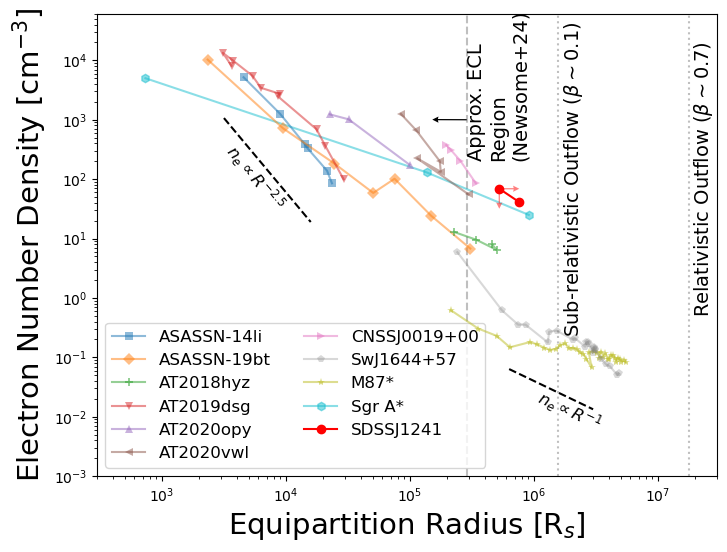

In [51]:
lit_density_profiles = pd.read_csv("density_profile_litTDEs.csv", index_col=0)
bh_masses = pd.read_csv("bh_masses_host.txt", sep="\t")
bh_masses["R_s"] = R_s((10**bh_masses.bhmass.to_numpy())*c.M_sun)

SCALE = 5

ecle_zorder = 100
tde_zorder = 50
bh_zorder = 25
fill_zorder = 1

symbs = ["o", "s", "D", "P", "v", "^", "<", ">", "p", "*", "h", "d", "x", "H"]
symbs_idx = 0

name_map = {
    "SwJ1644+57" : "Sw J1644+57",
    #"CNSSJ0019+00" : "CNSS J0019+00"
}

# now plot the n_e values on a n_e vs. radius

fig, ax = plt.subplots(figsize=(8,6))

color_dict = {
    "SDSSJ1241" : "red",
    "SDSSJ0938" : "blue",
    "SDSSJ0748" : "black"
}

names_to_plot = {"SDSSJ1241"}


ax.set_xscale("log")
ax.set_yscale("log")

# add the ECLE density profiles
for name, grp in results_df.groupby("name"):
    
    if name not in names_to_plot: continue
    
    yerr = [(0,0)]*len(grp)
    if len(grp[~grp.n_e_lim]) > 0:
        yerr = [(r.n_e_up, r.n_e_lo) if not r.n_e_lim else (0, 0) for _,r in grp.iterrows()]
        
    xerr = [(0,0)]*len(grp)
    if len(grp[~grp.Req_lim]) > 0:
        xerr = [(r.Req_up, r.Req_lo) if not r.Req_lim else (0, 0) for _,r in grp.iterrows()]
    
    ax.errorbar(
        grp.Req/grp.R_s,
        grp.n_e,
        #yerr = yerr,
        #xerr = xerr,
        color = color_dict[name],
        label = name,
        linestyle = "-",
        marker = symbs[symbs_idx],
        capsize = 3,
        zorder = ecle_zorder
    )
    
    print(grp.n_e)
    
    symbs_idx += 1
    
    r_lim = grp[grp.Req_lim]
    direction = "left" if r_lim.Req_lim_type.iloc[0] == "upper" else "right"
    draw_limit_arrow(r_lim, ax, direction, color=color_dict[name], alpha=0.5, scale=SCALE, zorder=ecle_zorder)
    
    ne_lim = grp[grp.n_e_lim]
    direction = "down" if r_lim.n_e_lim_type.iloc[0] == "upper" else "up"
    draw_limit_arrow(ne_lim, ax, direction, color=color_dict[name], alpha=0.5, scale=SCALE, zorder=ecle_zorder)

# add literature Density profiles
for name, grp in lit.groupby("Name"):
    
    if name in name_map:
        # then just plot the literature ones 
        # some of these are more complex to calculate than others so we will defer to the
        # literature values
        lit_densities = lit_density_profiles[lit_density_profiles.name == name_map[name]]
        
        ax.plot(
            lit_densities["R/Rs"],
            lit_densities.n,
            marker = symbs[symbs_idx],
            linestyle = '-',
            alpha=0.3,
            label=name,
            zorder = tde_zorder,
            mew=0
        )
        
        symbs_idx += 1
        
        continue
    
    r_s = bh_masses[bh_masses.name == name].R_s.values[0]
    ax.plot(
        grp.Req/r_s,
        grp.n_e,
        marker = symbs[symbs_idx],
        linestyle = '-',
        alpha=0.5,
        label=name,
        zorder = tde_zorder,
        mew=0
    )
    symbs_idx += 1

# add Sgr A* and M87*
for bh,kwargs in zip(['M87*', 'Sgr A*'], [{"mew":0},{}]):
    lit_densities = lit_density_profiles[lit_density_profiles.name == bh]
        
    ax.plot(
        lit_densities["R/Rs"],
        lit_densities.n,
        marker = symbs[symbs_idx],
        linestyle = '-',
        alpha=0.5,
        label=bh,
        zorder=bh_zorder,
        **kwargs
    )
    
    symbs_idx += 1
    
ax.set_ylabel(r"Electron Number Density [cm$^{-3}$]", fontsize=21)
ax.set_xlabel(r"Equipartition Radius [R$_{{s}}$]", fontsize=21)

ax.set_xlim(3e2, 3e7)
ax.set_ylim(1e-3, 6e4)

# plot some literature values for the [Fe X] radius of different ECLEs
ax.axvline(
    np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]), 
    alpha=0.25, 
    # label="22upj [Fe X] Radius\n(Newsome+24)",
    zorder = fill_zorder,
    linestyle = "--",
    color = "k"
)

ax.text(
    np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]),
    2e2,
    "Approx. ECL\nRegion\n(Newsome+24)",
    rotation=90,
    fontsize=14,
    verticalalignment="bottom",
    horizontalalignment="left"
)

ax.quiver(
    np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]),
    1e3,
    -np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]) * (1-1/10),
    1e3,
    width=0.002,
    headwidth=5,
    scale_units="inches",
    **kwargs
)

# ax.axvline(
#     1.22e17/R_s(1e6*c.M_sun),
#     alpha=0.25,
#     label="19qiz [Fe X] Radius\n2020 (Short+23)",
#     zorder = fill_zorder,
#     linestyle = ":",
#     color = "k"
# )

# ax.axvline(
#     1.47e17/R_s(1e6*c.M_sun),
#     alpha=0.25,
#     label="19qiz [Fe X] Radius\n2021 (Short+23)",
#     zorder = fill_zorder,
#     linestyle = "-.",
#     color = "k"
# )

# acak = np.array([1047.2,	842.3,	788.6,	823.1,	978.1])
# ax.axvline(
#     virial_r(acak, M=) / 
# )

R = np.logspace(3.5, 4.2)
k = 6e11
ax.plot(R, k*R**-2.5, linestyle='--', color='k')
ax.text(3e3, 3e1, r"$n_e \propto R^{-2.5}$", rotation=-50, fontsize=12)

R = np.logspace(5.8, np.log10(3e6))
k = 4e4
ax.plot(R, k*R**-1, linestyle='--', color='k')
ax.text(1e6, 6e-3, r"$n_e \propto R^{-1}$", rotation=-25, fontsize=12)

# fit the SDSS J1241 two data points
# xvals = np.logspace(2, 8)
# j1241 = results_df[results_df.name == "SDSSJ1241"]
# fit_result = np.polyfit(np.log10(j1241.Req/j1241.R_s), np.log10(j1241.n_e), 1)
# yvals = np.polyval(fit_result, np.log10(xvals))

# ymin = np.ones(len(xvals)) * j1241.n_e.min()
# ax.fill_between(xvals, ymin, 10**yvals, color='r', alpha=0.1, zorder=fill_zorder, edgecolor="w")

# ax.text(4e6, 1.5e0, fr"$n_e \propto R^{{{fit_result[0]:.2f}}}$", rotation=-36, fontsize=10)

# plot vertical lines at the locations of the outflow if it is relativistic or sub-relativistic
R_slow = (dR(0.1) + ref_R) / R_s_j1241
ax.axvline(
    R_slow, # sub-relativistic
    alpha=0.25, 
    zorder = fill_zorder,
    linestyle = ":",
    color = "k"
)
ax.text(
    R_slow+1e5,
    1e2,
    r"Sub-relativistic Outflow ($\beta \sim 0.1$)",
        rotation=90,
    fontsize=14,
    verticalalignment="center",
    horizontalalignment="left"
)

R_fast = (dR(0.7) + ref_R) / R_s_j1241
ax.axvline(
    R_fast, # relativistic
    alpha=0.25, 
    zorder = fill_zorder,
    linestyle = ":",
    color = "k"
)
ax.text(
    R_fast+1e6,
    1e2,
    r"Relativistic Outflow ($\beta \sim 0.7$)",
    rotation=90,
    fontsize=14,
    verticalalignment="center",
    horizontalalignment="left"
)

ax.legend(loc="lower left", fontsize=12, ncols=2)

fig.savefig("ecle-density-profile-w-reference-labels.png")

(0.897475,
 BinomTestResult(k=1, n=8, alternative='greater', statistic=0.125, pvalue=0.5791000463332314))

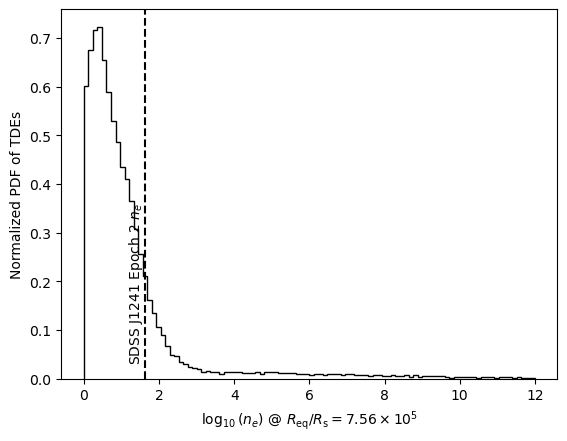

In [15]:
dets = results_df[results_df.n_e_lim  == False]
x_to_eval = (dets.Req/dets.R_s).values[0]
yval = dets.n_e.values[0]

n_e_pred = []
for name, grp in lit.groupby("Name"):
    
    if name in name_map:
        
        lit_densities = lit_density_profiles[lit_density_profiles.name == name_map[name]]
        
        x = lit_densities["R/Rs"]
        y = lit_densities.n
    
    else:
        r_s = bh_masses[bh_masses.name == name].R_s.values[0]

        x = grp.Req.values/r_s
        y = grp.n_e.values
    
    fit, cov = np.polyfit(np.log10(x), np.log10(y), 1, cov=True)
    m_err, y0_err = cov[0][0], cov[1][1]
    m, y0 = fit
    
    m_arr = np.random.normal(m, m_err, size=10_000)
    y0_arr = np.random.normal(y0, y0_err, size=10_000)
    
    y_pred = [np.polyval(v, np.log10(x_to_eval)) for v in zip(m_arr, y0_arr)]
    
    n_e_pred += y_pred

# histogram all of these values
fig, ax = plt.subplots()

n_e_samp = np.array(n_e_pred)
ax.hist(n_e_samp, bins=100, range=(0,12), color='k', histtype="step", density=True, label="Resampled TDE Population")
ax.axvline(np.log10(yval), linestyle="--", color="k")
ax.text(np.log10(yval), 0.04, r"SDSS J1241 Epoch 2 $n_e$", rotation=90, fontsize=10, horizontalalignment="right")
ax.set_ylabel("Normalized PDF of TDEs")
ax.set_xlabel(rf"$\log_{{10}}\left(n_e\right)$ @ $R_{{\rm eq}}/R_{{\rm s}} = {x_to_eval/1e5:.2f}\times10^{5}$")

# plot best fit stat distribution
# from scipy.stats import lognorm as pdist

# best_fit = pdist.fit(n_e_samp)

# xfit = np.linspace(0, 12, 1000)
# res_dist = pdist(*best_fit)
# res = res_dist.pdf(xfit)
# ax.plot(xfit, 3*res, color="r", label="Log-Norm Best Fit PDF")
# ax.legend()

from scipy.stats import binomtest

n_gtr = len(n_e_samp[n_e_samp > np.log10(yval)])
n = len(n_e_samp)
quant = 1 - n_gtr / n

res = binomtest(1, len(lit.Name.unique()), p=1-quant, alternative="greater") # add one because we are adding one more "point" to the literature

fig.savefig("n_e-comparison-hist.png")

quant, res

In [16]:
results_df

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,Req_up,Req_lo,Req_lim,Req_lim_type,Eeq_chain,Eeq,Eeq_up,Eeq_lo,Eeq_lim,Eeq_lim_type
0,SDSSJ1241,57959.0,3.920903,0.055025,0.083077,"[3.0049657740184856, 3.0010281263657257, 3.000...",1.175365,0.016536,0.018017,"[0.9909119054822503, 0.9941782983059854, 1.001...",...,3.622871e+16,3.341431e+16,False,lower,"[2.9910243711663864e+50, 2.989837019993387e+50...",2.606995e+51,3.112666e+50,3.574675e+50,False,lower
1,SDSSJ1241,57629.5,3.877922,0.085578,0.076951,"[3.9340857138140164, 3.9190376794936714, 3.914...",1.083294,0.265146,0.111470,"[1.0086813402090888, 1.0041549375264336, 1.001...",...,6.295742e+17,1.574242e+17,True,lower,"[1.5573237250441273e+51, 1.5835970460267922e+5...",1.487861e+51,3.289258e+51,5.981312e+50,True,lower
2,SDSSJ0938,57912.0,3.081853,0.122519,0.081857,"[3.0010275068929424, 2.990421810647745, 3.0069...",1.297415,0.464983,0.293400,"[0.9922377944666052, 1.0054323015722957, 0.992...",...,2.806105e+19,4.872137e+18,True,lower,"[2.5179387318845983e+51, 2.54816117608244e+51,...",2.825269e+52,2.652492e+53,2.102897e+52,True,lower
3,SDSSJ0938,57459.0,3.112252,0.092424,0.095087,"[3.0833806643032777, 3.072689053518213, 3.0783...",1.309558,0.471109,0.473921,"[0.9954455437367415, 1.002645844777471, 1.0036...",...,2.044444e+19,4.370534e+18,True,lower,"[2.9649083082551087e+51, 3.060581635902947e+51...",2.403624e+52,2.274829e+53,2.179525e+52,True,lower
4,SDSSJ0748,57914.0,2.590281,0.340513,0.306848,"[2.9971661030039187, 2.9927683159084366, 2.993...",0.409951,0.844192,0.713918,"[1.0032325646876552, 1.0047088985977595, 1.007...",...,2.192994e+20,8.351557e+18,True,lower,"[7.87075090092076e+50, 7.875833133689492e+50, ...",1.457429e+51,1.512122e+53,1.431416e+51,True,lower
5,SDSSJ0748,57458.0,2.615977,0.128486,0.125098,"[2.5893171848730145, 2.5979619176830204, 2.580...",0.645441,0.887906,0.891467,"[0.9920297540159176, 1.0077216786031211, 0.993...",...,2.560428e+20,7.522309e+18,True,lower,"[3.32080831774024e+50, 3.546122422168809e+50, ...",2.127404e+51,3.177684e+53,2.113024e+51,True,lower


[4897.  4567.5]
2
1


/tmp/ipykernel_63784/2865328009.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grp['t'] = dt


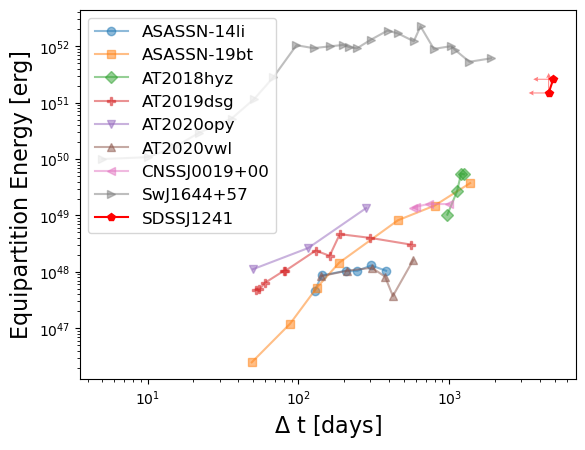

In [42]:
fig, ax = plt.subplots()

symbs_idx = 0
label_idx = 0
names = []

xkey = "t"
        
for name, grp in lit.groupby("Name"):   

    
    ax.errorbar(
        grp[xkey], #[label_idx],
        grp.Eeq,
        marker = symbs[symbs_idx],
        linestyle = "-",
        label = name,
        zorder = -100,
        alpha=0.5,
        # mew=0,
        # color = color_dict[name]
    )
    
    # ax.axvline(label_idx-0.5, color='k', alpha=0.1)
    
    symbs_idx += 1
    label_idx += 1
    names.append(name)
    
# add the ECLE density profiles
for name in ["SDSS_J1241"]: #, "SDSS_J0938", "SDSS_J0748"]:
    
    label_name = name.replace("_", "")
    grp = results_df[results_df.name == label_name]
    
    # if name not in names_to_plot: continue
    if xkey == "t":
        meta = db.get_meta(names=name, query_private=True)
        dd = meta[0].get_discovery_date().mjd
        dt = grp.mjd.values.astype(float) - dd
        print(dt)
        grp['t'] = dt
        
    yerr = [(0,0)]*len(grp)
    if len(grp[~grp.Eeq_lim]) > 0:
        yerr = [(r.Eeq_up, r.Eeq_lo) if not r.Eeq_lim else (0, 0) for _,r in grp.iterrows()]
        
    xerr = [(0,0)]*len(grp)
    if xkey != "t" and len(grp[~grp.Req_lim]) > 0:
        xerr = [(r.Req_up, r.Req_lo) if not r.Req_lim else (0, 0) for _,r in grp.iterrows()]
    
    ax.errorbar(
        grp[xkey],
        grp.Eeq,
        #yerr = yerr,
        #xerr = xerr,
        color = color_dict[label_name],
        label = label_name,
        linestyle = "-",
        marker = symbs[symbs_idx],
        capsize = 3,
        zorder = ecle_zorder
    )
    
    
    symbs_idx += 1
    
    if xkey == "Req":
        r_lim = grp[grp.Req_lim]
        direction = "left" if r_lim.Req_lim_type.iloc[0] == "upper" else "right"
        draw_limit_arrow(r_lim, ax, direction, color=color_dict[label_name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)
    elif xkey == "t":
        draw_limit_arrow(grp, ax, "left", color=color_dict[label_name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)
    else:
        raise ValueError()
    
    E_lim = grp[grp.Eeq_lim]
    direction = "down" if E_lim.Eeq_lim_type.iloc[0] == "upper" else "up"
    draw_limit_arrow(E_lim, ax, direction, color=color_dict[label_name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)

    
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel(r"$\Delta$ t [days]", fontsize=16)
ax.set_ylabel("Equipartition Energy [erg]", fontsize=16)

ax.legend(fontsize=12)

fig.savefig("ecle-energy-comparison.png", bbox_inches="tight")

[[4.65373265e+47]
 [1.29969906e+48]]
[[2.49075172e+46]
 [3.75601953e+49]]
[[1.03545737e+49]
 [5.55082286e+49]]
[[4.80523801e+47]
 [4.66959866e+48]]
[[1.11748919e+48]
 [1.35018002e+49]]
[[3.74054284e+47]
 [1.61959215e+48]]
[[1.34239144e+49]
 [1.60318953e+49]]
[[1.00267920e+50]
 [2.26172821e+52]]
['lower' 'lower']
2
2
['lower' 'lower']
2
2
['lower']
1
1


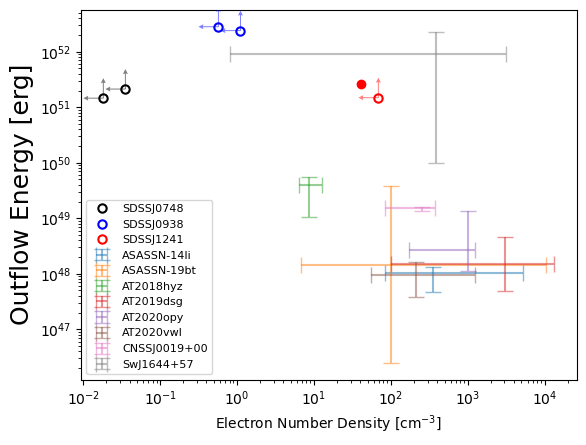

In [18]:
fig, ax = plt.subplots()

symbs_idx = 0
label_idx = 0
names = []
names_to_plot = ["SDSSJ1241"]

        
for name, grp in lit.groupby("Name"):   
    print(np.array(list(zip([grp.Eeq.min()], [grp.Eeq.max()]))).T)
    ax.errorbar(
        grp.n_e.median(), #[label_idx],
        grp.Eeq.median(),
        yerr = np.array(list(zip([grp.Eeq.median()-grp.Eeq.min()], [grp.Eeq.max()-grp.Eeq.median()]))).T,
        xerr = np.array(list(zip([grp.n_e.median()-grp.n_e.min()], [grp.n_e.max()-grp.n_e.median()]))).T,
        marker = "none",
        linestyle = "none",
        label = name,
        zorder = -100,
        alpha=0.5,
        # mew=0,
        capsize=6
    )
    
    # ax.axvline(label_idx-0.5, color='k', alpha=0.1)
    
    symbs_idx += 1
    label_idx += 1
    names.append(name)
    
# ax.axvline(label_idx-0.5, color='k')
    
for name, grp in results_df.groupby("name"):
    
    # if name not in names_to_plot: continue
    
    lum_dist = grp.lum_dist.values[0]
    
    lims = grp[grp.log_F_nu_lim]
    
#     ax.plot(
#         np.ones(len(lims))*label_idx,
#         lims.Eeq.values,
#         marker = symbs[symbs_idx],
#         linestyle = "none",
#         label = name,
#         color = color_dict[name]
#     )
    
#     ax.quiver(
#         np.ones(len(lims))*label_idx,
#         lims.Eeq.values,
#         np.zeros(len(lims)),
#         np.ones(len(lims)),
#         width=0.002,
#         headwidth=5,
#         scale_units="inches",
#         color = color_dict[name]
#     )
    
# #     ax.quiver(
# #         [np.median(v) for v in lims.beta_chain.values],
#         lims.Eeq.values,
#         np.ones(len(lims)),
#         np.zeros(len(lims)),
#         width=0.002,
#         headwidth=5,
#         scale_units="inches",
#         color = color_dict[name]
#     )
    
    nolim = grp[~grp.log_F_nu_lim]
    # print(nolim.Eeq.values)
    if len(nolim) > 0:
        ax.errorbar(
            nolim.n_e.values, #np.ones(len(nolim))*label_idx,
            nolim.Eeq.values,
            yerr = nolim[["Eeq_up", "Eeq_lo"]].values.T,
            linestyle = "none",
            marker = "o",
            # label = name,
            color = color_dict[name]
        )
        
    if len(lims) > 0:
        ax.plot(
            lims.n_e.values, #np.ones(len(lims))*label_idx,
            lims.Eeq.values,
            linestyle = "none",
            marker = "o",
            markerfacecolor='w',
            markeredgewidth=1.5, 
            markeredgecolor=color_dict[name],
            label = name
        )
        print(lims.Req_lim_type.values)
        direction = "left" if lims.n_e_lim_type.values[0] == "upper" else "right"
        draw_limit_arrow(lims, ax, direction, color=color_dict[name], alpha=0.5, xkey="n_e", ykey="Eeq", scale=SCALE, zorder=ecle_zorder)

        direction = "down" if lims.Eeq_lim_type.values[0] == "upper" else "up"
        draw_limit_arrow(lims, ax, direction, color=color_dict[name], alpha=0.5, xkey="n_e", ykey="Eeq", scale=SCALE, zorder=ecle_zorder)
        
    symbs_idx += 1
    label_idx += 1
    
    names.append(name)
    
# ax.set_xlabel(r"Object Name")
ax.set_ylabel(r"Outflow Energy [erg]", fontsize=18)
ax.set_xlabel(r"Electron Number Density [cm$^{-3}$]")

ax.set_yscale("log")
ax.set_xscale("log")
# ax.set_xscale("log")
# ax.set_xticks(list(range(label_idx)))
# ax.set_xticklabels(names, rotation=45, fontsize=14, horizontalalignment="right")
# ax.legend(loc="best", fontsize=6, ncols=2);

ax.legend(fontsize=8)

fig.savefig("ecle-energy-comparison.png")

In [19]:
lims

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,Req_up,Req_lo,Req_lim,Req_lim_type,Eeq_chain,Eeq,Eeq_up,Eeq_lo,Eeq_lim,Eeq_lim_type
1,SDSSJ1241,57629.5,3.877922,0.085578,0.076951,"[3.9340857138140164, 3.9190376794936714, 3.914...",1.083294,0.265146,0.11147,"[1.0086813402090888, 1.0041549375264336, 1.001...",...,6.295742e+17,1.574242e+17,True,lower,"[1.5573237250441273e+51, 1.5835970460267922e+5...",1.487861e+51,3.289258e+51,5.981312e+50,True,lower
